Total points : 15000
Lags par courbe : 50
Nombre de couples (paires de neurones) calculés : 300
Indices des couples les plus actifs : [  4 130 272  66 245]


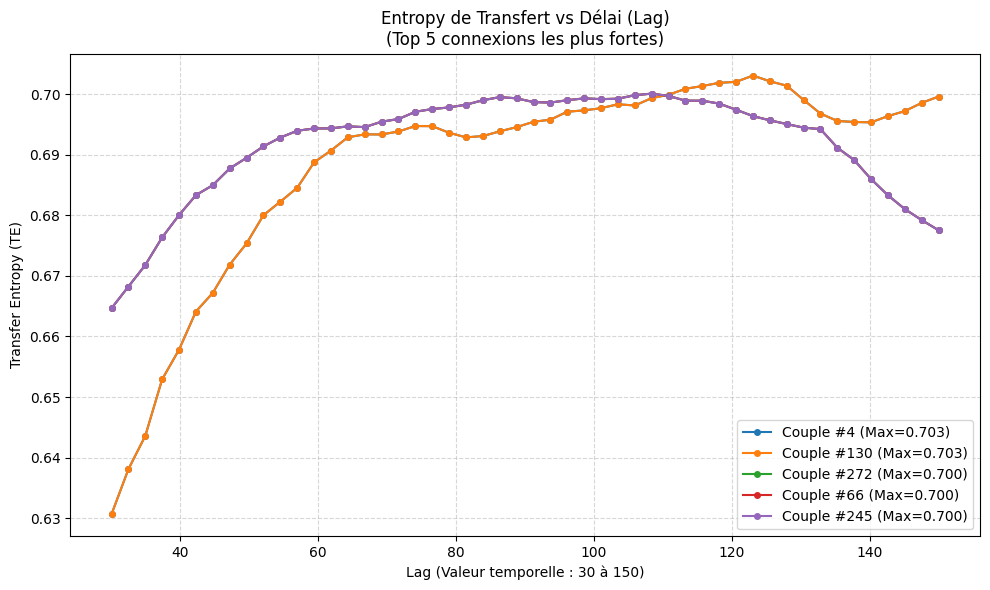

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
file_path = '/Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output/20260112-232029_measure_TE_sweep/52b65bdd_tensors/te_tensor_eps1.300_cr0.41_977787346.npz'

# Paramètres issus de ta confirmation
n_lags = 50
lag_values = np.linspace(30, 150, n_lags)  # L'axe X correct

# ==========================================
# 2. CHARGEMENT ET RESHAPE
# ==========================================
try:
    data = np.load(file_path, allow_pickle=True)
    te_flat = data['te_values']
    
    # Vérification
    total_points = te_flat.size
    n_couples = total_points // n_lags
    
    print(f"Total points : {total_points}")
    print(f"Lags par courbe : {n_lags}")
    print(f"Nombre de couples (paires de neurones) calculés : {n_couples}")
    
    if total_points % n_lags != 0:
        raise ValueError(f"Erreur dimensionnelle : {total_points} n'est pas divisible par {n_lags}")

    # On remet en forme : (Nombre de couples, 50 points de lag)
    te_matrix = te_flat.reshape((n_couples, n_lags))

    # ==========================================
    # 3. SELECTION DES MEILLEURS COUPLES
    # ==========================================
    # On cherche les couples qui ont le plus fort pic (max TE)
    # pour éviter de tracer du bruit plat.
    
    max_te_per_couple = np.max(te_matrix, axis=1)
    
    # On prend les indices des 5 connections les plus fortes
    # argsort trie du plus petit au plus grand, on prend les derniers [-5:]
    top_indices = np.argsort(max_te_per_couple)[-5:]
    
    # On inverse pour avoir le champion en premier dans la légende
    top_indices = top_indices[::-1] 

    print(f"Indices des couples les plus actifs : {top_indices}")

    # ==========================================
    # 4. TRACÉ
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    for idx in top_indices:
        te_curve = te_matrix[idx, :]
        max_val = np.max(te_curve)
        
        plt.plot(lag_values, te_curve, marker='o', markersize=4, 
                 label=f'Couple #{idx} (Max={max_val:.3f})')

    plt.title("Entropy de Transfert vs Délai (Lag)\n(Top 5 connexions les plus fortes)")
    plt.xlabel("Lag (Valeur temporelle : 30 à 150)")
    plt.ylabel("Transfer Entropy (TE)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Erreur : {e}")


Recherche des fichiers dans : /Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output ...
50 fichiers CSV trouvés au total.
50 fichiers valides fusionnés.
Graphique généré et sauvegardé ici : /Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output/Global_Heatmap_TE.png


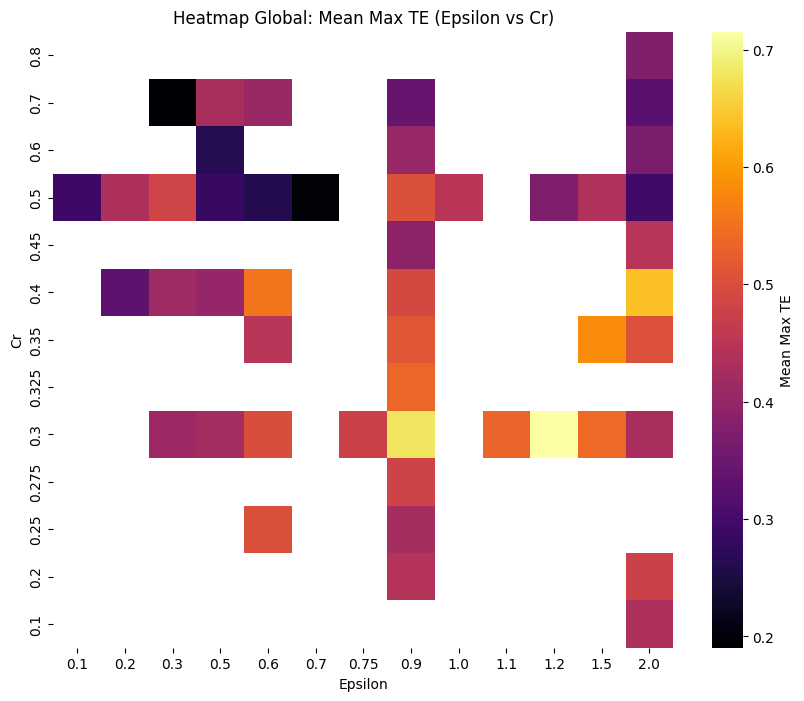

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# 1. Configuration du chemin racine
# On pointe vers le dossier "Data_output"
base_dir = "/Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output"

# 2. Recherche récursive de tous les CSV
# Le pattern "**/*.csv" avec recursive=True dit : "Cherche dans ce dossier et tous les sous-dossiers"
print(f"Recherche des fichiers dans : {base_dir} ...")
chemin_recherche = os.path.join(base_dir, "**", "*.csv")
fichiers = glob.glob(chemin_recherche, recursive=True)

print(f"{len(fichiers)} fichiers CSV trouvés au total.")

# 3. Chargement et filtrage
data_frames = []
colonnes_requises = {'epsilon', 'cr', 'mean_max_TE'}

# Compteur pour le suivi
count = 0

for fichier in fichiers:
    try:
        # On lit le CSV
        df_temp = pd.read_csv(fichier)
        
        # On vérifie si ce CSV contient bien nos données (au cas où il y ait d'autres csv parasites)
        if colonnes_requises.issubset(df_temp.columns):
            # On ne garde que les colonnes utiles pour alléger la mémoire
            data_frames.append(df_temp[list(colonnes_requises)])
            count += 1
            
    except Exception as e:
        # Si un fichier est corrompu ou illisible, on l'ignore juste
        continue

if not data_frames:
    print("Erreur : Aucun fichier valide contenant 'epsilon', 'cr' et 'mean_max_TE' n'a été trouvé.")
    exit()

print(f"{count} fichiers valides fusionnés.")

# 4. Fusion des données
df_global = pd.concat(data_frames, ignore_index=True)

# Gestion des doublons : Si tu as plusieurs simulations pour les mêmes paramètres,
# pivot_table va faire la moyenne des résultats par défaut (aggfunc='mean').
df_pivot = df_global.pivot_table(index="cr", columns="epsilon", values="mean_max_TE", aggfunc='mean')

# Trier l'axe Y (cr) pour avoir les grandes valeurs en haut (convention graphique)
df_pivot = df_pivot.sort_index(ascending=False)

# 5. Tracé de la Heatmap
plt.figure(figsize=(10, 8))

# Palette de couleurs 'inferno' ou 'magma' pour un effet "chaleur"
ax = sns.heatmap(df_pivot, annot=False, cmap="inferno", cbar_kws={'label': 'Mean Max TE'})

plt.title("Heatmap Global: Mean Max TE (Epsilon vs Cr)")
plt.xlabel("Epsilon")
plt.ylabel("Cr")

# Sauvegarde dans le dossier racine Data_output
output_file = os.path.join(base_dir, "Global_Heatmap_TE.png")
plt.savefig(output_file, dpi=300, bbox_inches='tight')

print(f"Graphique généré et sauvegardé ici : {output_file}")
plt.show()


Recherche dans : /Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output/20260113-172957_measure_TE_sweep ...
Graphique sauvegardé : /Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output/20260113-172957_measure_TE_sweep/Scaled_Heatmap_TE.png


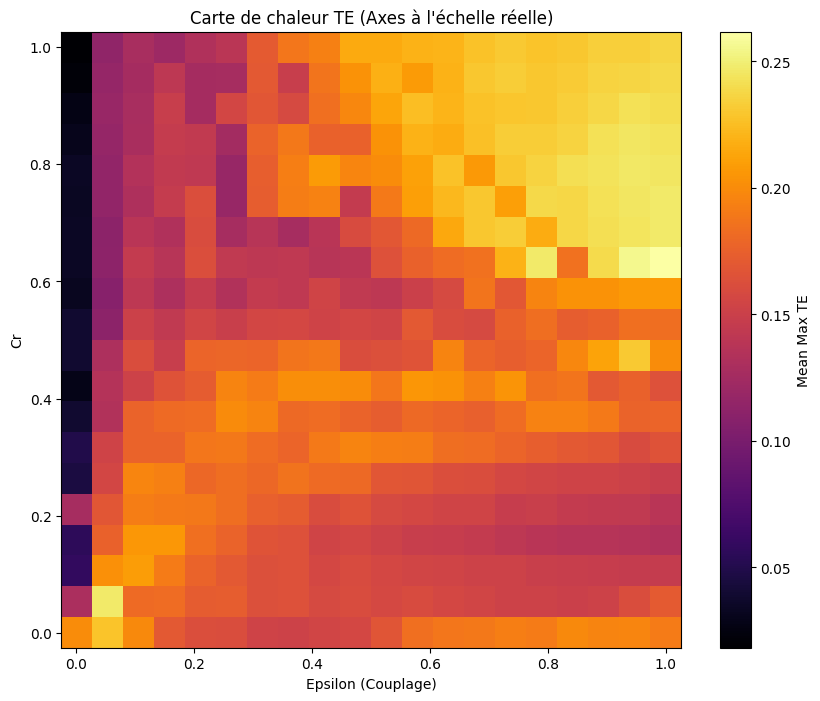

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

# 1. Configuration et chargement (identique à avant)
base_dir = "/Users/constantindeumier/Desktop/Dev_Numerical_project/pass/Numerical_Project/run/Data_output/20260113-172957_measure_TE_sweep"
chemin_recherche = os.path.join(base_dir, "**", "*.csv")

print(f"Recherche dans : {base_dir} ...")
fichiers = glob.glob(chemin_recherche, recursive=True)

data_frames = []
colonnes_requises = {'epsilon', 'cr', 'mean_max_TE'}

for fichier in fichiers:
    try:
        df_temp = pd.read_csv(fichier)
        if colonnes_requises.issubset(df_temp.columns):
            data_frames.append(df_temp[list(colonnes_requises)])
    except:
        continue

if not data_frames:
    print("Aucune donnée trouvée.")
    exit()

df_global = pd.concat(data_frames, ignore_index=True)

# 2. Création de la matrice (Pivot)
# On fait la moyenne si plusieurs points ont les mêmes coordonnées
df_pivot = df_global.pivot_table(index="cr", columns="epsilon", values="mean_max_TE", aggfunc='mean')

# Pour pcolormesh, il est préférable de trier les index et colonnes
df_pivot = df_pivot.sort_index(ascending=True) # cr croissant
df_pivot = df_pivot.sort_index(axis=1, ascending=True) # epsilon croissant

# 3. Préparation des coordonnées pour Matplotlib
# X correspond aux colonnes (epsilon), Y aux index (cr)
X_val = df_pivot.columns.values  # Liste des epsilons
Y_val = df_pivot.index.values    # Liste des cr
Z_val = df_pivot.values          # La matrice des couleurs (TE)

# On crée une grille 2D
X, Y = np.meshgrid(X_val, Y_val)

# 4. Tracé avec pcolormesh (Respecte l'échelle mathématique)
plt.figure(figsize=(10, 8))

# shading='nearest' centre la couleur sur la coordonnée.
# shading='auto' ou 'gouraud' (pour lisser) sont aussi possibles.
# vmin et vmax peuvent être fixés si tu veux bloquer l'échelle de couleur.
mesh = plt.pcolormesh(X, Y, Z_val, cmap='inferno', shading='nearest')

# Ajout de la barre de couleur
cbar = plt.colorbar(mesh)
cbar.set_label('Mean Max TE')

# Titres et Axes
plt.title("Carte de chaleur TE (Axes à l'échelle réelle)")
plt.xlabel("Epsilon (Couplage)")
plt.ylabel("Cr")

# Si tu as des données logarithmiques, tu peux décommenter ces lignes :
# plt.xscale('log') 
# plt.yscale('log')

# Sauvegarde
output_file = os.path.join(base_dir, "Scaled_Heatmap_TE.png")
plt.savefig(output_file, dpi=300, bbox_inches='tight')

print(f"Graphique sauvegardé : {output_file}")
plt.show()


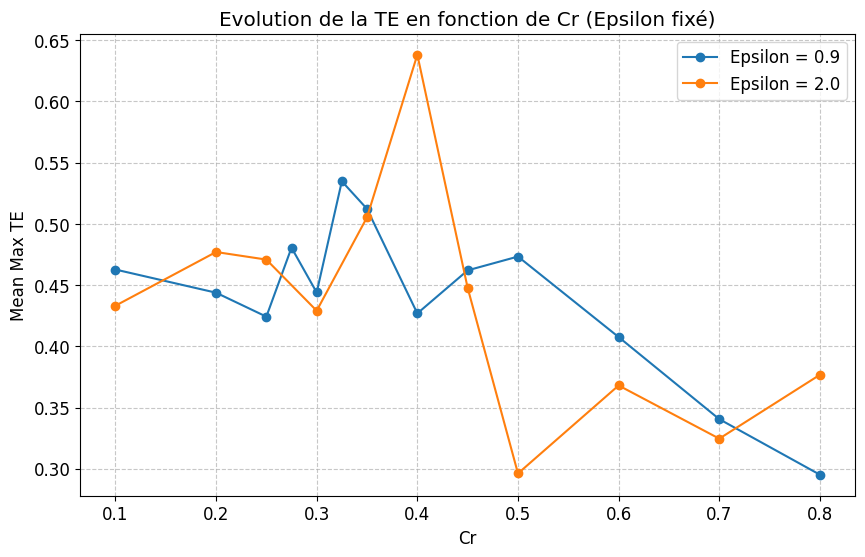

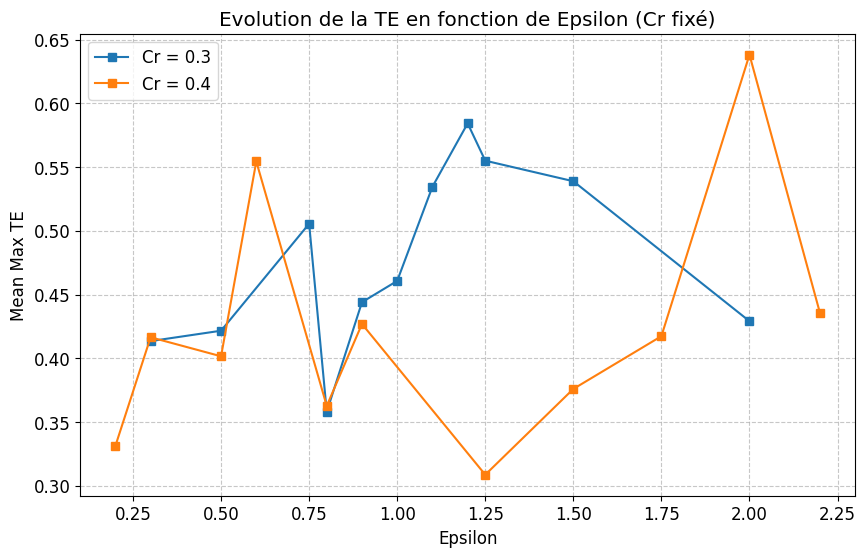

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Je suppose que 'df_global' est déjà chargé grâce au code précédent.
# Si ce n'est pas le cas, relance la partie chargement des CSV.

# --- Configuration Esthétique ---
plt.rcParams.update({'font.size': 12})

# ==========================================
# PARTIE 1 : Fixer Epsilon -> Tracer TE = f(Cr)
# ==========================================
target_epsilons = [0.9, 2.0]  # Les valeurs que tu veux fixer

plt.figure(figsize=(10, 6))

for eps in target_epsilons:
    # 1. Filtrage : On cherche les lignes où epsilon est proche de la valeur cible
    # atol=1e-5 signifie qu'on tolère une toute petite différence (pour éviter les bugs de float)
    mask = np.isclose(df_global['epsilon'], eps, atol=1e-5)
    subset = df_global[mask]
    
    # 2. Tri : Important pour que la ligne soit tracée dans l'ordre
    subset = subset.sort_values(by='cr')
    
    # 3. Vérification : Si pas de données, on prévient
    if subset.empty:
        print(f"⚠️ Attention: Aucune donnée trouvée pour Epsilon = {eps}")
    else:
        # Aggregation : au cas où tu as plusieurs points pour un même Cr (moyenne)
        subset_mean = subset.groupby('cr')['mean_max_TE'].mean()
        
        # 4. Tracé
        plt.plot(subset_mean.index, subset_mean.values, marker='o', label=f'Epsilon = {eps}')

plt.title("Evolution de la TE en fonction de Cr (Epsilon fixé)")
plt.xlabel("Cr")
plt.ylabel("Mean Max TE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# ==========================================
# PARTIE 2 : Fixer Cr -> Tracer TE = f(Epsilon)
# ==========================================
target_crs = [0.3, 0.4]  # Les valeurs que tu veux fixer

plt.figure(figsize=(10, 6))

for cr_val in target_crs:
    # 1. Filtrage : On cherche les lignes où Cr est proche de la valeur cible
    mask = np.isclose(df_global['cr'], cr_val, atol=1e-5)
    subset = df_global[mask]
    
    # 2. Tri : Important pour l'axe X (Epsilon)
    subset = subset.sort_values(by='epsilon')
    
    # 3. Vérification
    if subset.empty:
        print(f"⚠️ Attention: Aucune donnée trouvée pour Cr = {cr_val}")
    else:
        # Aggregation : au cas où doublons
        subset_mean = subset.groupby('epsilon')['mean_max_TE'].mean()
        
        # 4. Tracé
        plt.plot(subset_mean.index, subset_mean.values, marker='s', label=f'Cr = {cr_val}')

plt.title("Evolution de la TE en fonction de Epsilon (Cr fixé)")
plt.xlabel("Epsilon")
plt.ylabel("Mean Max TE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Tu peux activer l'échelle log si epsilon varie beaucoup
# plt.xscale('log') 

plt.show()
